In [45]:
import os
import re
import time
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from collections import Counter

# ⚠️ 중요: 반드시 konlpy/tag 임포트 '전'에 실행해야 적용됩니다.
# JVM의 최대 힙 메모리를 4기가바이트(-Xmx4g)로 확장 설정
os.environ['JVM_ARGS'] = '-Xmx4g'
import konlpy
from konlpy.tag import Mecab, Kkma, Okt
from gensim.models.word2vec import Word2Vec
import sentencepiece as spm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.nn.utils.rnn import pad_sequence


# init config
# 한글 폰트 설정 (주피터 노트북 시각화 대응)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 디바이스 지정 (GPU 가속 지원)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# 데이터셋 기본 경로
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'sentiment_classification')


print(torch.__version__)
print(np.__version__)
print(konlpy.__version__)

device: cuda
2.7.1+cu126
1.26.4
0.6.0


In [53]:
# define

# ---------------------------------------------------------------------------
# [정밀 매핑] 제공된 sp_tokenize 기반 및 가변 경로 제어 보완
# ---------------------------------------------------------------------------
def sp_tokenize(s, corpus, vocab_dir):
    """
    s: 학습 및 로드 완료된 sentencepiece 모델 인스턴스
    corpus: 문장 데이터 리스트 (pd.Series 혹은 list)
    vocab_dir: .vocab 파일이 저장된 절대/상대 디렉토리 경로
    """
    tensor = []
    for sen in corpus:
        if not isinstance(sen, str):
            sen = str(sen) if pd.notnull(sen) else ""
        tensor.append(s.EncodeAsIds(sen))

    # 지정된 경로에서 .vocab 파일 확보
    vocab_path = os.path.join(vocab_dir, "korean_spm.vocab")
    if not os.path.exists(vocab_path):
        # 다중 튜닝 실험 시 가변 파일명이 생성되므로 폴더 내 매칭 유연화
        import glob
        found_vocabs = glob.glob(os.path.join(vocab_dir, "*.vocab"))
        if found_vocabs:
            vocab_path = found_vocabs[0]
        else:
            raise FileNotFoundError(f"⚠️ {vocab_dir} 디렉토리 내에 .vocab 파일이 존재하지 않습니다.")

    with open(vocab_path, 'r', encoding='utf-8') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]
        word_index[word] = idx
        index_word[idx] = word

    # 빈 리스트 변환 및 다차원 정수 스태킹 처리
    tensor_tensors = [torch.tensor(t) if len(t) > 0 else torch.tensor([0]) for t in tensor]
    tensor = pad_sequence(tensor_tensors, batch_first=True, padding_value=0)

    return tensor, word_index, index_word


def train_spm_tokenizer(input_txt_path, vocab_size, model_type, output_dir):
    """지정된 디렉토리에 SentencePiece 모델을 학습하여 저장하고 인스턴스를 반환합니다."""
    os.makedirs(output_dir, exist_ok=True)
    model_prefix = os.path.join(output_dir, f"spm_{model_type}_{vocab_size}")
    
    templates = (
        f"--input={input_txt_path} "
        f"--model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} "
        f"--model_type={model_type} "
        f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
    )
    spm.SentencePieceTrainer.Train(templates)
    
    sp_instance = spm.SentencePieceProcessor()
    sp_instance.Load(f"{model_prefix}.model")
    return sp_instance


# ---------------------------------------------------------------------------
# DataHandler: KoNLPy 3종 분기 및 SentencePiece 인터페이스 일원화
# ---------------------------------------------------------------------------
class DataHandler:
    def __init__(self, tokenizer=None, stopwords=None):
        self.tokenizer = tokenizer
        self.raw_train_data = None
        self.raw_test_data = None
        self.stopwords = stopwords if stopwords is not None else []

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.word_index = None

    def load_data(self, train_data_path: str, test_data_path: str):
        if os.path.exists(train_data_path) and os.path.exists(test_data_path):
            self.raw_train_data = pd.read_table(train_data_path)
            self.raw_test_data = pd.read_table(test_data_path)
        else:
            raise FileNotFoundError(f"⚠️ 데이터 파일 경로를 다시 확인해주세요.\nTrain: {train_data_path}\nTest: {test_data_path}")

    def clean_and_drop(self):
        self.raw_train_data.drop_duplicates(subset=['document'], inplace=True)
        self.raw_test_data.drop_duplicates(subset=['document'], inplace=True)
        self.raw_train_data.dropna(how='any', inplace=True)        
        self.raw_test_data.dropna(how='any', inplace=True)

    def process_konlpy(self, num_words=10000):
        """Mecab, Kkma, Okt 인스턴스를 가변 수용하는 통합 형태소 분석 전처리"""
        self.clean_and_drop()
        if self.tokenizer is None:
            raise ValueError("KoNLPy 형태소 훈련 분석을 위해 tokenizer 인스턴스 주입이 필수적입니다.")

        X_train_tokens = []
        for sentence in self.raw_train_data['document']:
            temp_X = self.tokenizer.morphs(str(sentence))
            temp_X = [word for word in temp_X if word not in self.stopwords]
            X_train_tokens.append(temp_X)

        X_test_tokens = []
        for sentence in self.raw_test_data['document']:
            temp_X = self.tokenizer.morphs(str(sentence))
            temp_X = [word for word in temp_X if word not in self.stopwords]
            X_test_tokens.append(temp_X)

        # 사전 및 정수 인덱스 빌드
        words = np.concatenate(X_train_tokens).tolist()
        counter = Counter(words).most_common(num_words - 4)
        
        vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
        word_to_index = {word: index for index, word in enumerate(vocab)}

        def wordlist_to_indexlist(wordlist):
            return [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in wordlist]

        self.X_train = list(map(wordlist_to_indexlist, X_train_tokens))
        self.X_test = list(map(wordlist_to_indexlist, X_test_tokens))
        
        self.X_train = [torch.tensor(seq) if len(seq) > 0 else torch.tensor([0]) for seq in self.X_train]
        self.X_test = [torch.tensor(seq) if len(seq) > 0 else torch.tensor([0]) for seq in self.X_test]

        self.y_train = np.array(list(self.raw_train_data['label']))
        self.y_test = np.array(list(self.raw_test_data['label']))
        self.word_index = {index: word for word, index in word_to_index.items()}

    def process_sentencepiece(self, sp_model, vocab_dir):
        self.clean_and_drop()
        
        # document와 label을 확실하게 리스트로 동시 확보하여 순서 고정
        documents = self.raw_train_data['document'].tolist()
        labels = self.raw_train_data['label'].tolist()
        
        X_train_tensor, word_index, index_word = sp_tokenize(sp_model, documents, vocab_dir=vocab_dir)
        
        self.X_train = X_train_tensor
        self.y_train = np.array(labels)  # 동기화된 레이블 주입
        
        # Test 데이터도 동일하게 처리
        test_documents = self.raw_test_data['document'].tolist()
        test_labels = self.raw_test_data['label'].tolist()
        
        X_test_tensor, _, _ = sp_tokenize(sp_model, test_documents, vocab_dir=vocab_dir)
        self.X_test = X_test_tensor
        self.y_test = np.array(test_labels)
        
        self.word_index = index_word

    def get_preprocessed_train_test_data_and_word_to_index(self):
        return self.X_train, self.y_train, self.X_test, self.y_test, self.word_index


# ---------------------------------------------------------------------------
# LSTM 공통 모델 아키텍처
# ---------------------------------------------------------------------------
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()
        # 1. 임베딩 레이어 (패딩 0번 묵음 처리)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. 양방향(Bidirectional) LSTM 및 2차원 깊이(num_layers=2) 적용
        # 양방향 구조이므로 출력 hidden 차원이 2배가 됩니다.
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True,
            dropout=dropout_rate if dropout_rate > 0 else 0  # 레이어 간 드롭아웃
        )
        
        # 3. Fully Connected (FC) 레이어 2층 구조로 확장
        # 양방향 정방향/역방향 hidden state가 결합되므로 입력 차원은 hidden_dim * 2 입니다.
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()                             # 👈 요청하신 중간 활성화 함수 ReLU
        self.dropout = nn.Dropout(p=dropout_rate)         # 👈 FC 레이어 사이의 드롭아웃
        self.fc2 = nn.Linear(hidden_dim, 1)               # 최종 차원 축소
        
        self.sigmoid = nn.Sigmoid()                       # 이진 분류를 위한 최종 확률 매핑

    def forward(self, x):
        # [Batch, Seq_len] -> [Batch, Seq_len, Embedding_dim]
        embedded = self.embedding(x)
        
        # LSTM 통과 -> out 형상: [Batch, Seq_len, Hidden_dim * 2]
        out, (hidden, _) = self.lstm(embedded)
        
        # 양방향 LSTM의 마지막 레이어(Layer 2)의 정방향(Forward)과 역방향(Backward) 은닉 상태 추출
        # PyTorch 양방향 LSTM에서 hidden 상태의 마지막 레이어 두 가닥은 각각 -2, -1 인덱스에 위치합니다.
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        
        # 두 상태를 Feature 차원(dim=1)을 기준으로 결합 (Concatenate)
        # 형상: [Batch, Hidden_dim * 2]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        # Fully Connected Layer 내부 연산 흐름
        fc1_out = self.fc1(hidden_concat)
        fc1_activated = self.relu(fc1_out)
        fc1_dropped = self.dropout(fc1_activated)
        
        # 최종 출력 및 시그모이드 통과
        logits = self.fc2(fc1_dropped)
        return self.sigmoid(logits).squeeze(-1)
# ---------------------------------------------------------------------------
# TrainHandler: 실험 모델 트래킹 인프라
# ---------------------------------------------------------------------------
class TrainHandler:
    def __init__(self, X_train, y_train, X_test, y_test, word_index):
        self.raw_X_train = X_train
        self.raw_y_train = y_train
        self.raw_X_test = X_test
        self.raw_y_test = y_test
        self.word_index = word_index
        self.vocab_size = max(word_index.keys()) + 1
        
        self.X_train_padded = None
        self.X_test_padded = None
        self.train_loader = None
        self.val_loader = None
        self.test_loader = None
        
        self.models = {}
        self.histories = {}

    def prepare_tensors(self, max_len=50):
        if isinstance(self.raw_X_train, torch.Tensor):
            if max_len is not None and max_len < self.raw_X_train.shape[1]:
                self.X_train_padded = self.raw_X_train[:, :max_len]
                self.X_test_padded = self.raw_X_test[:, :max_len]
            else:
                self.X_train_padded = self.raw_X_train
                self.X_test_padded = self.raw_X_test
        else:
            X_train_truncated = [seq[:max_len] if len(seq) > 0 else torch.tensor([0]) for seq in self.raw_X_train]
            X_test_truncated = [seq[:max_len] if len(seq) > 0 else torch.tensor([0]) for seq in self.raw_X_test]
            
            self.X_train_padded = pad_sequence(X_train_truncated, batch_first=True, padding_value=0)
            self.X_test_padded = pad_sequence(X_test_truncated, batch_first=True, padding_value=0)

    def make_validation_set(self, val_ratio=0.2, batch_size=256):
        full_dataset = TensorDataset(self.X_train_padded.long(), torch.tensor(self.raw_y_train, dtype=torch.float32))
        test_dataset = TensorDataset(self.X_test_padded.long(), torch.tensor(self.raw_y_test, dtype=torch.float32))

        val_size = int(len(full_dataset) * val_ratio)
        train_size = len(full_dataset) - val_size

        train_dataset, val_dataset = random_split(
            full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
        )

        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        self.test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    def config_model(self, model_key, embedding_dim=100, hidden_dim=128):
        # 파라미터는 동일하되 내부 레이어 아키텍처가 고도화된 인스턴스를 주입합니다.
        self.models[model_key] = LSTMModel(
            vocab_size=self.vocab_size, 
            embedding_dim=embedding_dim, 
            hidden_dim=hidden_dim,
            dropout_rate=0.3  # 기본값 0.3 지정
        ).to(device)


    def train_model(self, model_key, epochs=5, lr=0.001, patience=4):
        model = self.models[model_key]
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        
        # 💡 [핵심 수정] 에폭별 시각화 데이터를 차곡차곡 누적할 빈 리스트 생성
        train_losses = []
        val_losses = []
        val_accuracies = []
        
        for epoch in range(epochs):
            # ==========================================
            # 1. 훈련 루프 (TRAIN LOOP)
            # ==========================================
            model.train()
            tr_loss = 0.0
            for inputs, labels in self.train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float().view(-1)
                
                optimizer.zero_grad()
                outputs = model(inputs).view(-1)
                loss = criterion(outputs, labels)
                
                loss.backward()
                optimizer.step()
                tr_loss += loss.item() * inputs.size(0)

            # ==========================================
            # 2. 검증 루프 (VALIDATION LOOP)
            # ==========================================
            model.eval()
            val_loss = 0.0
            val_correct = 0
            with torch.no_grad():
                for inputs, labels in self.val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device).float().view(-1)
                    
                    outputs = model(inputs).view(-1)
                    val_loss += criterion(outputs, labels).item() * inputs.size(0)
                    
                    preds = (outputs >= 0.5).float()
                    val_correct += (preds == labels).sum().item()
            
            epoch_tr_loss = tr_loss / len(self.train_loader.dataset)
            epoch_val_loss = val_loss / len(self.val_loader.dataset)
            epoch_val_acc = val_correct / len(self.val_loader.dataset)

            # 💡 [핵심 수정] 매 에폭의 연산 결과를 리스트에 실시간 append
            train_losses.append(epoch_tr_loss)
            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            # 조기 종료(Early Stopping) 체크 및 최적 가중치 저장
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f" Early Stopping triggered at epoch {epoch+1}")
                    break

        # 최적의 상태 복원
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # ==========================================
        # 3. 최종 평가 루프 (TEST LOOP)
        # ==========================================
        model.eval()
        test_correct = 0
        with torch.no_grad():
            for inputs, labels in self.test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float().view(-1)
                
                outputs = model(inputs).view(-1)
                preds = (outputs >= 0.5).float()
                test_correct += (preds == labels).sum().item()
        
        test_acc = test_correct / len(self.test_loader.dataset)
        print(f"📊 [{model_key}] Test Accuracy: {test_acc:.4f}")
        
        # 💡 [핵심 수정] 에폭 흐름 전체가 담긴 리스트 통째로 histories에 주입
        # 만약 객체 내부에 histories가 초기화 안되어 있다면 생성 (딕셔너리 구조 보장)
        if not hasattr(self, 'histories'):
            self.histories = {}
            
        self.histories[model_key] = {
            'train_loss': train_losses,
            'val_loss': val_losses,
            'val_acc': val_accuracies
        }
        
        return test_acc



In [39]:
# ---------------------------------------------------------------------------
# [기능 1] OOV (UNK) 비율 계산 함수
# ---------------------------------------------------------------------------
def calculate_oov_ratio(token_tensors, unk_idx=2):
    """
    정수 인덱싱이 완료된 텐서 리스트/행렬에서 UNK(OOV) 토큰이 차지하는 비율을 계산합니다.
    (패딩 토큰인 0번은 계산에서 제외하여 실제 단어 중 OOV 비율을 산출)
    """
    total_tokens = 0
    unk_tokens = 0
    
    if isinstance(token_tensors, torch.Tensor):
        # SentencePiece 등 2차원 정적 텐서 구조인 경우
        flat_tokens = token_tensors.numpy().flatten()
    else:
        # KoNLPy 등 리스트 내 1차원 텐서 구조인 경우
        flat_tokens = np.concatenate([t.numpy() for t in token_tensors])
        
    # 패딩(0)을 제외한 실제 유효 토큰 필터링
    valid_tokens = flat_tokens[flat_tokens != 0]
    
    total_tokens = len(valid_tokens)
    unk_tokens = np.sum(valid_tokens == unk_idx)
    
    if total_tokens == 0:
        return 0.0
    return (unk_tokens / total_tokens) * 100


# ---------------------------------------------------------------------------
# [기능 2] Loss & Accuracy 시각화 차트 생성
# ---------------------------------------------------------------------------
def plot_learning_curves(histories):
    """
    histories: { 'Model_Key': { 'train_loss': [...], 'val_loss': [...], 'val_acc': [...] }, ... }
    각 토크나이저 실험별 Train/Val Loss 및 Accuracy 추이를 서브플롯으로 그립니다.
    """
    num_models = len(histories)
    if num_models == 0:
        print("⚠️ 시각화할 학습 이력(History) 데이터가 없습니다.")
        return
        
    fig, axes = plt.subplots(num_models, 2, figsize=(14, 4 * num_models))
    if num_models == 1:
        axes = np.expand_dims(axes, axis=0) # 모델이 1개일 때 차원 예외 처리
        
    for idx, (model_key, history) in enumerate(histories.items()):
        epochs = range(1, len(history['train_loss']) + 1)
        
        # Left: Loss Curve
        axes[idx, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
        axes[idx, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
        axes[idx, 0].set_title(f"[{model_key}] Loss Curve")
        axes[idx, 0].set_xlabel("Epochs")
        axes[idx, 0].set_ylabel("Loss")
        axes[idx, 0].legend()
        axes[idx, 0].grid(True)
        
        # Right: Accuracy Curve
        axes[idx, 1].plot(epochs, history['val_acc'], 'g-^', label='Val Accuracy')
        axes[idx, 1].set_title(f"[{model_key}] Validation Accuracy")
        axes[idx, 1].set_xlabel("Epochs")
        axes[idx, 1].set_ylabel("Accuracy")
        axes[idx, 1].legend()
        axes[idx, 1].grid(True)
        
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# [기능 3] 토크나이저 최종 성능 및 지표 비교표 데이터프레임 생성
# ---------------------------------------------------------------------------
def create_comparison_table(performance_results, oov_results, histories):
    """
    종합 평가지표 서머리 테이블을 빌드하고 시각화 바 차트를 출력합니다.
    """
    report_data = []
    for model_key in performance_results.keys():
        # 각 모델별 최적 Validation Accuracy 추출
        best_val_acc = max(histories[model_key]['val_acc']) if model_key in histories else np.nan
        
        report_data.append({
            "Tokenizer Strategy": model_key,
            "Test Accuracy": performance_results[model_key],
            "Best Val Accuracy": best_val_acc,
            "Test OOV (UNK) Ratio (%)": oov_results.get(model_key, 0.0)
        })
        
    df_compare = pd.DataFrame(report_data)
    df_compare = df_compare.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
    
    print("\n" + "="*70)
    print("🏆 토크나이저 벤치마크 최종 데이터 분석 결과표")
    print("="*70)
    print(df_compare.to_string(index=False))
    print("="*70)
    
    # 성능 비교 바 차트 추가 시각화
    plt.figure(figsize=(10, 5))
    sns.barplot(x="Test Accuracy", y="Tokenizer Strategy", data=df_compare, palette="viridis")
    plt.axvline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
    plt.title("토크나이저별 최종 Test Accuracy 비교")
    plt.xlim(0.45, 0.90)
    plt.grid(True, axis='x')
    plt.legend()
    plt.show()
    
    return df_compare

In [ ]:
if __name__ == "__main__":
    # 데이터셋 로드 정밀 절대 경로 지정
    DATA_DIR = os.path.join(os.getcwd(), '..', '..', 'work', 'sentiment_classification', 'data')
    TRAIN_PATH = os.path.join(DATA_DIR, 'ratings_train.txt')
    TEST_PATH = os.path.join(DATA_DIR, 'ratings_test.txt')

    # # -------------------------------------------------------------
    # # [안정성 보완] 쾌적한 릴레이 실험을 위한 샘플링 다운사이징 (선택)
    # # -------------------------------------------------------------
    # # 원본 파일이 너무 크고 Kkma가 느리므로 빠른 경향성 파악을 위해 3만 건만 샘플링
    # df_train_tmp = pd.read_table(TRAIN_PATH).dropna().sample(n=30000, random_state=42)
    # df_test_tmp = pd.read_table(TEST_PATH).dropna().sample(n=10000, random_state=42)
    
    # # 임시 파일로 저장하여 하위 파이프라인이 이 샘플을 바라보게 변경
    # TRAIN_PATH = os.path.join(DATA_DIR, 'ratings_train_sample.txt')
    # TEST_PATH = os.path.join(DATA_DIR, 'ratings_test_sample.txt')
    
    # df_train_tmp.to_csv(TRAIN_PATH, sep='\t', index=False)
    # df_test_tmp.to_csv(TEST_PATH, sep='\t', index=False)
    # # -------------------------------------------------------------

    # SPM 전용 저장 상대/절대 디렉토리 경로 지정
    SPM_DIR = os.path.join(os.getcwd(), '..', '..', 'work', 'data', 'ex06')
    os.makedirs(SPM_DIR, exist_ok=True)

    # 불용어 정의
    stopwords = ['의','가','이','은','들','는','과','도','를','으로','자','에','와','한','하다']
    
    # 최종 성능 스토리지
    performance_results = {}

    # =======================================================================
    # 파트 1. KoNLPy 형태소 분석기 3종 (Mecab, Kkma, Okt) 릴레이 벤치마크
    # =======================================================================
    konlpy_tokenizers = {
        'Mecab': Mecab(),
        # 'Kkma': Kkma(),
        'Okt': Okt()
    }

    for name, tokenizer_obj in konlpy_tokenizers.items():
        print(f"\n🚀 [실험 RUN] KoNLPy - {name} 파이프라인 가동 중...")
        try:
            handler = DataHandler(tokenizer=tokenizer_obj, stopwords=stopwords)
            handler.load_data(TRAIN_PATH, TEST_PATH)
            handler.process_konlpy(num_words=10000)
            
            X_tr, y_tr, X_te, y_te, w_idx = handler.get_preprocessed_train_test_data_and_word_to_index()
            
            trainer = TrainHandler(X_tr, y_tr, X_te, y_te, w_idx)
            trainer.prepare_tensors(max_len=50)
            trainer.make_validation_set(batch_size=256)
            trainer.config_model(name)
            
            acc = trainer.train_model(name, epochs=3)
            performance_results[name] = acc
        except Exception as e:
            print(f"❌ {name} 형태소 분석 중 에러 발생 (건너뜀): {e}")

    # =======================================================================
    # 파트 2. SentencePiece (SPM) 하이퍼파라미터 가변 교차 검증 실험
    # =======================================================================
    print("\n--- SentencePiece 학습 소스 추출 중 ---")
    df_src = pd.read_table(TRAIN_PATH).dropna()
    temp_corpus_path = os.path.join(SPM_DIR, "corpus_src.txt")
    with open(temp_corpus_path, "w", encoding="utf-8") as f:
        f.write("\n".join(df_src['document'].tolist()))

    # 실험 하이퍼파라미터 그리드 매트릭스 선언
    spm_experiments = [
        {"model_type": "unigram", "vocab_size": 8000},
        {"model_type": "unigram", "vocab_size": 16000},
        {"model_type": "bpe", "vocab_size": 8000},
        {"model_type": "bpe", "vocab_size": 16000},
    ]

    for exp in spm_experiments:
        m_type = exp["model_type"]
        v_size = exp["vocab_size"]
        exp_key = f"SPM_{m_type.upper()}_Vocab{v_size}"
        
        print(f"\n🚀 [실험 RUN] {exp_key} 토크나이저 빌드 및 훈련 가동...")
        
        # 1. 모델 개별 저장 생성 및 반환
        sp_model = train_spm_tokenizer(
            input_txt_path=temp_corpus_path, 
            vocab_size=v_size, 
            model_type=m_type, 
            output_dir=SPM_DIR
        )
        
        # 2. 전처리 핸들러 매핑
        spm_handler = DataHandler()
        spm_handler.load_data(TRAIN_PATH, TEST_PATH)
        spm_handler.process_sentencepiece(sp_model=sp_model, vocab_dir=SPM_DIR)
        
        X_tr, y_tr, X_te, y_te, w_idx = spm_handler.get_preprocessed_train_test_data_and_word_to_index()
        
        # 3. 데이터 로더 구성 및 가중치 수렴
        trainer = TrainHandler(X_tr, y_tr, X_te, y_te, w_idx)
        trainer.prepare_tensors(max_len=50)
        trainer.make_validation_set(batch_size=256)
        trainer.config_model(exp_key)
        
        acc = trainer.train_model(exp_key, epochs=3)
        performance_results[exp_key] = acc

    # =======================================================================
    # 파트 3. 최종 스코어보드 종합 리포트 출력
    # =======================================================================
    print("\n" + "="*60)
    print("🏆 토크나이저별 네이버 영화 감정 분석 최종 성능 스코어보드")
    print("="*60)
    for model_name, score in performance_results.items():
        print(f" ▹ {model_name:<25} -> Test Accuracy: {score:.4f}")
    print("="*60)


🚀 [실험 RUN] KoNLPy - Mecab 파이프라인 가동 중...
📊 [Mecab] Test Accuracy: 0.6560

--- SentencePiece 학습 소스 추출 중 ---

🚀 [실험 RUN] SPM_UNIGRAM_Vocab8000 토크나이저 빌드 및 훈련 가동...
📊 [SPM_UNIGRAM_Vocab8000] Test Accuracy: 0.6519

🚀 [실험 RUN] SPM_UNIGRAM_Vocab16000 토크나이저 빌드 및 훈련 가동...
📊 [SPM_UNIGRAM_Vocab16000] Test Accuracy: 0.6004

🚀 [실험 RUN] SPM_BPE_Vocab8000 토크나이저 빌드 및 훈련 가동...
📊 [SPM_BPE_Vocab8000] Test Accuracy: 0.5815

🚀 [실험 RUN] SPM_BPE_Vocab16000 토크나이저 빌드 및 훈련 가동...
📊 [SPM_BPE_Vocab16000] Test Accuracy: 0.6053

🏆 토크나이저별 네이버 영화 감정 분석 최종 성능 스코어보드
 ▹ Mecab                     -> Test Accuracy: 0.6560
 ▹ SPM_UNIGRAM_Vocab8000     -> Test Accuracy: 0.6519
 ▹ SPM_UNIGRAM_Vocab16000    -> Test Accuracy: 0.6004
 ▹ SPM_BPE_Vocab8000         -> Test Accuracy: 0.5815
 ▹ SPM_BPE_Vocab16000        -> Test Accuracy: 0.6053



🚀 [실험 RUN] KoNLPy - Mecab 파이프라인 가동 중...
 Early Stopping triggered at epoch 8
📊 [Mecab] Test Accuracy: 0.8576

--- SentencePiece 학습 소스 추출 중 ---

🚀 [실험 RUN] SPM_UNIGRAM_Vocab8000 토크나이저 빌드 및 훈련 가동...
 Early Stopping triggered at epoch 8
📊 [SPM_UNIGRAM_Vocab8000] Test Accuracy: 0.8438

🚀 [실험 RUN] SPM_BPE_Vocab8000 토크나이저 빌드 및 훈련 가동...
 Early Stopping triggered at epoch 8
📊 [SPM_BPE_Vocab8000] Test Accuracy: 0.8456

🏆 토크나이저별 네이버 영화 감정 분석 최종 성능 스코어보드
 ▹ Mecab                     -> Test Accuracy: 0.8576
 ▹ SPM_UNIGRAM_Vocab8000     -> Test Accuracy: 0.8438
 ▹ SPM_BPE_Vocab8000         -> Test Accuracy: 0.8456
{'Mecab': {'train_loss': [0.4640007342040348, 0.3490058015369719, 0.30246441055485446, 0.2673241772973054, 0.23402438256385957, 0.2035602144976621, 0.17521585126636338, 0.14482660650801268], 'val_loss': [0.3851936786555448, 0.3442851774856287, 0.33245211800532065, 0.32634007480193755, 0.327291098811555, 0.3648886315953733, 0.3972908413178586, 0.42407950388698573], 'val_acc': [0.82559173

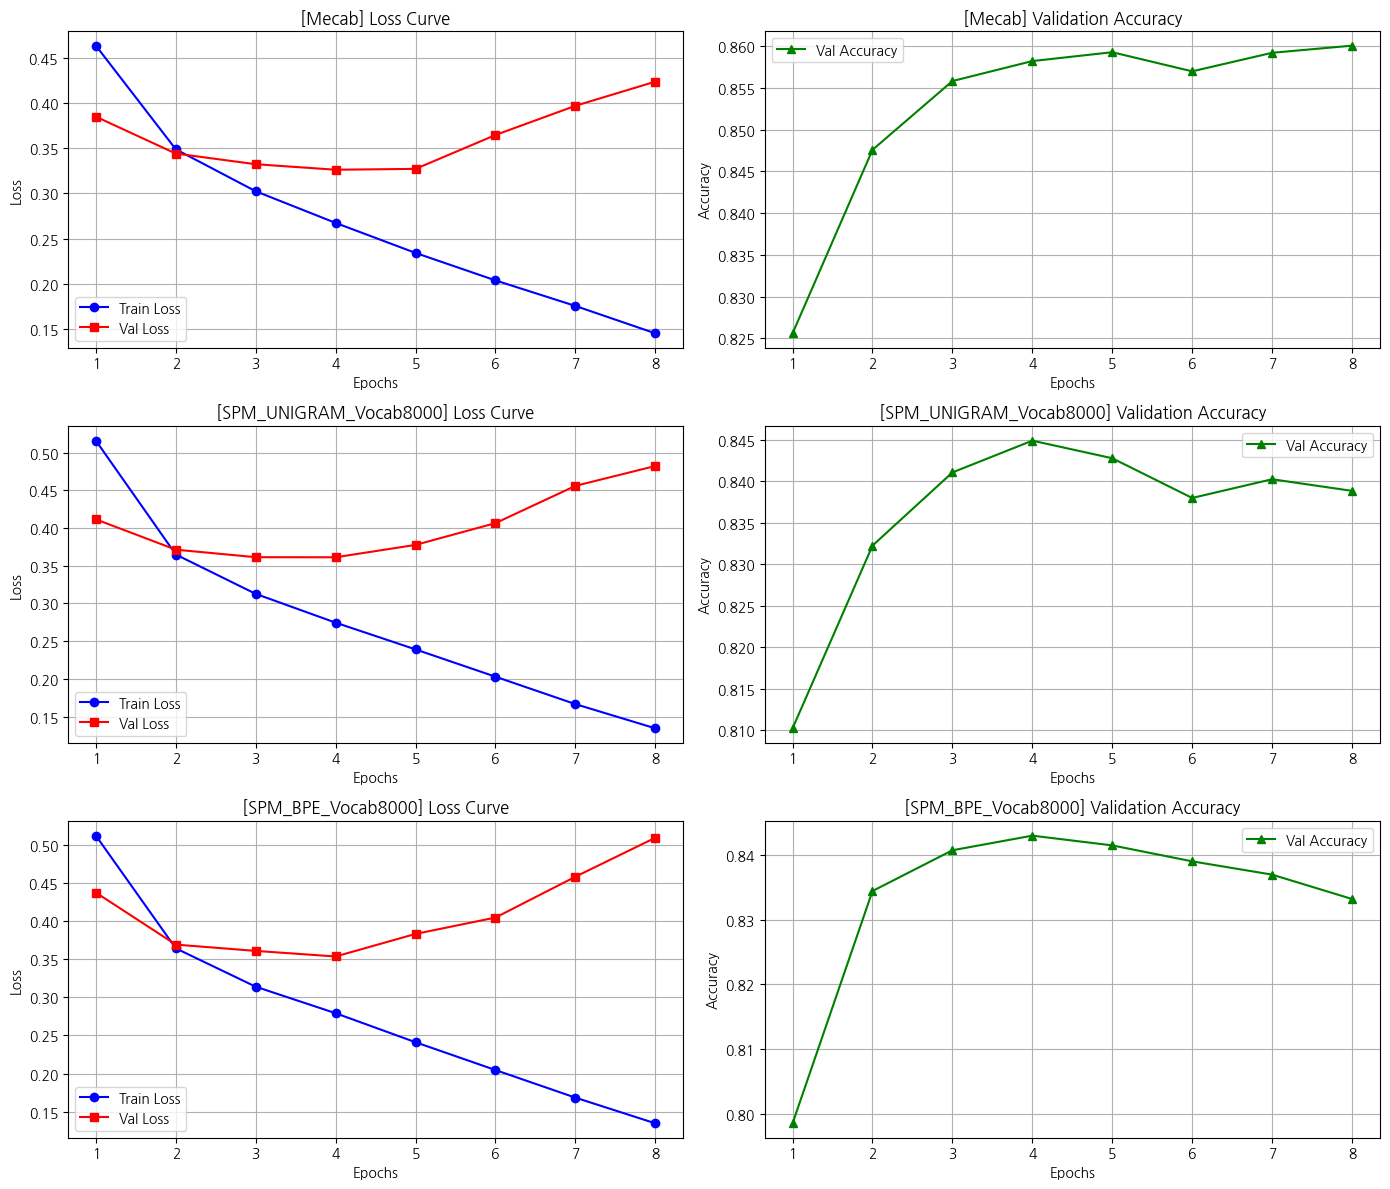


🏆 토크나이저 벤치마크 최종 데이터 분석 결과표
   Tokenizer Strategy  Test Accuracy  Best Val Accuracy  Test OOV (UNK) Ratio (%)
                Mecab       0.857558           0.860070                  3.920109
    SPM_BPE_Vocab8000       0.845576           0.842968                  0.106733
SPM_UNIGRAM_Vocab8000       0.843766           0.844917                  0.104354


/tmp/ipykernel_47187/3844838562.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Test Accuracy", y="Tokenizer Strategy", data=df_compare, palette="viridis")


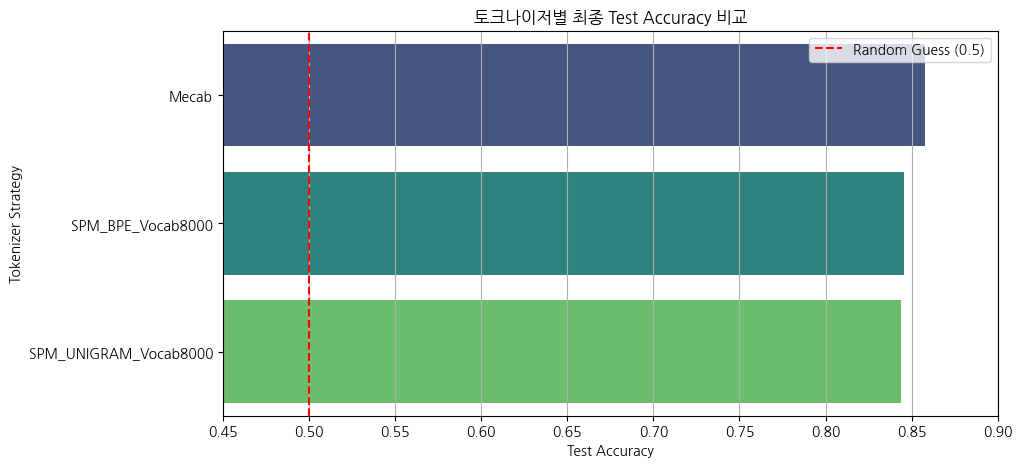

In [54]:
if __name__ == "__main__":
    # 데이터셋 로드 정밀 절대 경로 지정
    DATA_DIR = os.path.join(os.getcwd(), '..', '..', 'work', 'sentiment_classification', 'data')
    TRAIN_PATH = os.path.join(DATA_DIR, 'ratings_train.txt')
    TEST_PATH = os.path.join(DATA_DIR, 'ratings_test.txt')

    performance_results = {}
    oov_results = {}       # 👈 1. OOV 저장용 딕셔너리 신설
    all_histories = {}     # 👈 2. 전체 내역 저장용 딕셔너리 신설


    # # -------------------------------------------------------------
    # # [안정성 보완] 쾌적한 릴레이 실험을 위한 샘플링 다운사이징 (선택)
    # # -------------------------------------------------------------
    # # 원본 파일이 너무 크고 Kkma가 느리므로 빠른 경향성 파악을 위해 3만 건만 샘플링
    # df_train_tmp = pd.read_table(TRAIN_PATH).dropna().sample(n=30000, random_state=42)
    # df_test_tmp = pd.read_table(TEST_PATH).dropna().sample(n=10000, random_state=42)
    
    # # 임시 파일로 저장하여 하위 파이프라인이 이 샘플을 바라보게 변경
    # TRAIN_PATH = os.path.join(DATA_DIR, 'ratings_train_sample.txt')
    # TEST_PATH = os.path.join(DATA_DIR, 'ratings_test_sample.txt')
    
    # df_train_tmp.to_csv(TRAIN_PATH, sep='\t', index=False)
    # df_test_tmp.to_csv(TEST_PATH, sep='\t', index=False)
    # # -------------------------------------------------------------

    # SPM 전용 저장 상대/절대 디렉토리 경로 지정
    SPM_DIR = os.path.join(os.getcwd(), '..', '..', 'work', 'data', 'ex06')
    os.makedirs(SPM_DIR, exist_ok=True)

    # 불용어 정의
    stopwords = ['의','가','이','은','들','는','과','도','를','으로','자','에','와','한','하다']
    
    # 최종 성능 스토리지
    performance_results = {}

    # =======================================================================
    # 파트 1. KoNLPy 형태소 분석기 3종 (Mecab, Kkma, Okt) 릴레이 벤치마크
    # =======================================================================
    konlpy_tokenizers = {
        'Mecab': Mecab(),
        # 'Kkma': Kkma(),
        # 'Okt': Okt()
    }

    for name, tokenizer_obj in konlpy_tokenizers.items():
        print(f"\n🚀 [실험 RUN] KoNLPy - {name} 파이프라인 가동 중...")
        try:
            handler = DataHandler(tokenizer=tokenizer_obj)
            handler.load_data(TRAIN_PATH, TEST_PATH)
            handler.process_konlpy(num_words=10000)
            
            X_tr, y_tr, X_te, y_te, w_idx = handler.get_preprocessed_train_test_data_and_word_to_index()
            
            unk_target_idx = 2 if 'SPM' not in name else w_idx.get('<unk>', 3)
            oov_results[name] = calculate_oov_ratio(X_te, unk_idx=unk_target_idx)

            trainer = TrainHandler(X_tr, y_tr, X_te, y_te, w_idx)
            trainer.prepare_tensors(max_len=50)
            trainer.make_validation_set(batch_size=256)
            trainer.config_model(name)
            
            acc = trainer.train_model(name, epochs=10)
            performance_results[name] = acc
            all_histories[name] = trainer.histories[name] # 👈 4. 학습 기록 수집
        except Exception as e:
            print(f"❌ {name} 형태소 분석 중 에러 발생 (건너뜀): {e}")

    # =======================================================================
    # 파트 2. SentencePiece (SPM) 하이퍼파라미터 가변 교차 검증 실험
    # =======================================================================
    print("\n--- SentencePiece 학습 소스 추출 중 ---")
    df_src = pd.read_table(TRAIN_PATH).dropna()
    temp_corpus_path = os.path.join(SPM_DIR, "corpus_src.txt")
    with open(temp_corpus_path, "w", encoding="utf-8") as f:
        f.write("\n".join(df_src['document'].tolist()))

    # 실험 하이퍼파라미터 그리드 매트릭스 선언
    spm_experiments = [
        {"model_type": "unigram", "vocab_size": 8000},
        # {"model_type": "unigram", "vocab_size": 16000},
        {"model_type": "bpe", "vocab_size": 8000},
        # {"model_type": "bpe", "vocab_size": 16000},
    ]

    for exp in spm_experiments:
        m_type = exp["model_type"]
        v_size = exp["vocab_size"]
        exp_key = f"SPM_{m_type.upper()}_Vocab{v_size}"  # 👈 이 루프의 고유 이름표
        
        print(f"\n🚀 [실험 RUN] {exp_key} 토크나이저 빌드 및 훈련 가동...")
        
        # 1. 모델 개별 저장 생성 및 반환
        sp_model = train_spm_tokenizer(
            input_txt_path=temp_corpus_path, 
            vocab_size=v_size, 
            model_type=m_type, 
            output_dir=SPM_DIR
        )
        
        # 2. 전처리 핸들러 매핑
        spm_handler = DataHandler()
        spm_handler.load_data(TRAIN_PATH, TEST_PATH)
        spm_handler.process_sentencepiece(sp_model=sp_model, vocab_dir=SPM_DIR)
        
        X_tr, y_tr, X_te, y_te, w_idx = spm_handler.get_preprocessed_train_test_data_and_word_to_index()
        
        # 💡 [버그 수정 1] name 대신 exp_key를 기준으로 조건 검사 및 딕셔너리 저장
        unk_target_idx = 2 if 'SPM' not in exp_key else w_idx.get('<unk>', 3)
        oov_results[exp_key] = calculate_oov_ratio(X_te, unk_idx=unk_target_idx)

        # 3. 데이터 로더 구성 및 가중치 수렴
        trainer = TrainHandler(X_tr, y_tr, X_te, y_te, w_idx)
        trainer.prepare_tensors(max_len=50)
        trainer.make_validation_set(batch_size=256)
        trainer.config_model(exp_key)
        
        acc = trainer.train_model(exp_key, epochs=10)
        performance_results[exp_key] = acc
        
        # 💡 [버그 수정 2] name 대신 exp_key로 변경하여 매핑 일치
        all_histories[exp_key] = trainer.histories[exp_key]

    # =======================================================================
    # 파트 3. 최종 스코어보드 종합 리포트 출력
    # =======================================================================
    print("\n" + "="*60)
    print("🏆 토크나이저별 네이버 영화 감정 분석 최종 성능 스코어보드")
    print("="*60)
    for model_name, score in performance_results.items():
        print(f" ▹ {model_name:<25} -> Test Accuracy: {score:.4f}")
    print("="*60)
    print(all_histories)
    # =======================================================================
    # 모든 루프가 끝난 후 최종 시각화 콘솔 트리거 (최하단 배치)
    # =======================================================================
    plot_learning_curves(all_histories)
    df_final = create_comparison_table(performance_results, oov_results, all_histories)